# RAG Performance Analysis on TriviaQA

End-to-end retrieval-augmented generation benchmark on the TriviaQA
(`rc.wikipedia`) dataset.  The pipeline is:

1. **Corpus** — load TriviaQA questions and Wikipedia entity pages.
2. **Chunking** — split pages into fixed-size overlapping word windows.
3. **Retrieval** — BM25, TF-IDF, or dense sentence-transformer embeddings.
4. **Generation** — `google/flan-t5-base` (instruction-tuned, deterministic).
5. **Evaluation** — Exact-Match, Token-F1, Recall@k with 95% bootstrap CIs.

Five experiments are executed end-to-end inside this notebook:

| # | Variable | Fixed |
|---|----------|-------|
| 1 | retriever ∈ {BM25, TF-IDF, Dense} | chunk=128, k=5, instructed prompt |
| 2 | chunk size ∈ {64, 128, 256, 512} | dense, k=5, instructed prompt |
| 3 | k ∈ {1, 3, 5, 10} | dense, chunk=128, instructed prompt |
| 4 | prompt ∈ {concise, instructed} | dense, chunk=128, k=5 |
| 5 | RAG vs No-RAG baseline | dense, chunk=128, k=5, instructed prompt |

All results are cached as JSON to `results/`; figures land in `figures/`.
Cached embeddings and generation outputs live in `data/cache/` so re-running is cheap.


## 1. Setup — imports and global configuration

All hyperparameters live inside the `config` namespace below.
Changing a value there propagates through the entire pipeline.


In [13]:
import hashlib
import json
import logging
import os
import pickle
import re
import string
import sys
import time
from abc import ABC, abstractmethod
from collections import Counter
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
from tqdm.auto import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("rag_project")


In [14]:
class config:
    """Central configuration for all RAG experiments."""

    # ── Paths ────────────────────────────────────────────────
    ROOT_DIR    = Path.cwd()
    DATA_DIR    = ROOT_DIR / "data"
    RESULTS_DIR = ROOT_DIR / "results"
    FIGURES_DIR = ROOT_DIR / "figures"
    CACHE_DIR   = ROOT_DIR / "data" / "cache"

    # ── Dataset ──────────────────────────────────────────────
    DATASET_NAME    = "mandarjoshi/trivia_qa"  # HF requires namespace/name
    DATASET_CONFIG  = "rc"      # Open reading-comprehension config:
                                # pools wiki entity pages AND web search
                                # results into the corpus, so retrieval
                                # competes against genuine distractors
                                # rather than only curated evidence.
    DATASET_SPLIT   = "validation"
    NUM_QUESTIONS   = 100       # Fast-iteration default; bump to 500 (or
                                # 1000) for the final report run. Runtime
                                # scales roughly linearly.
    MAX_CORPUS_DOCS = 5000      # With MAX_SEARCH_RESULTS_PER_Q=5, 100 qs
                                # yield ~700-1500 unique docs; this is a
                                # safety ceiling, not a working limit.
    MAX_SEARCH_RESULTS_PER_Q = 5  # Take only the top-N web hits per qn.
                                  # rc ships 10-50 search results per qn;
                                  # the long tail mostly adds embedding
                                  # cost.  Set to None for no cap.

    # ── Chunking ─────────────────────────────────────────────
    CHUNK_SIZES        = [64, 128, 256, 512]
    CHUNK_OVERLAP      = 32
    DEFAULT_CHUNK_SIZE = 128

    # ── Retrieval ────────────────────────────────────────────
    RETRIEVER_TYPES  = ["bm25", "tfidf", "dense"]
    K_VALUES         = [1, 3, 5, 10]
    DEFAULT_K        = 5
    DENSE_MODEL      = "sentence-transformers/all-MiniLM-L6-v2"
    DENSE_BATCH_SIZE = 64

    # ── Generation ───────────────────────────────────────────
    GENERATOR_MODEL      = "google/flan-t5-base"
    MAX_INPUT_TOKENS     = 512    # Flan-T5-base's effective pre-training
                                  # context window. Going higher works
                                  # but pushes the encoder past sequences
                                  # it ever saw during training and quietly
                                  # degrades performance.
    MAX_NEW_TOKENS       = 32       # answers are almost always <10 tokens
    GENERATOR_BATCH_SIZE = 16

    # ── Evaluation ───────────────────────────────────────────
    BOOTSTRAP_SAMPLES = 1000
    RANDOM_SEED       = 42

    # ── Run control ──────────────────────────────────────────
    # When True, experiments always recompute even if a results JSON
    # already exists. Set False only if you want plot-only re-runs
    # off cached results.
    FORCE_RERUN = True

    # ── Prompting ────────────────────────────────────────────
    PROMPT_TEMPLATES = {
        # NB: question appears *before* and *after* the context. T5
        # truncation chops from the end, so a question only at the end
        # can be cut off when the context is long; repeating it at the
        # start keeps it visible even under aggressive truncation, while
        # the trailing "Answer:" still serves as the generation cue.
        "concise": (
            "Question: {question}\n\n"
            "Context:\n{context}\n\n"
            "Question: {question}\n"
            "Answer:"
        ),
        "instructed": (
            "You are a factual QA assistant. "
            "Read the context and answer the question with a short phrase only. "
            "Do NOT repeat the question. Do NOT write a sentence; just the answer.\n\n"
            "Question: {question}\n\n"
            "Context:\n{context}\n\n"
            "Question: {question}\n"
            "Short answer:"
        ),
        "no_context": (
            "Answer the following question with a short phrase.\n\n"
            "Question: {question}\n"
            "Short answer:"
        ),
    }
    DEFAULT_PROMPT = "instructed"


for _d in [config.DATA_DIR, config.RESULTS_DIR, config.FIGURES_DIR, config.CACHE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print("Working directory:", config.ROOT_DIR)
print("Results dir:      ", config.RESULTS_DIR)
print("Figures dir:      ", config.FIGURES_DIR)
print("Cache dir:        ", config.CACHE_DIR)


Working directory: c:\Users\Filip\Documents\ml-project\RAG_ML
Results dir:       c:\Users\Filip\Documents\ml-project\RAG_ML\results
Figures dir:       c:\Users\Filip\Documents\ml-project\RAG_ML\figures
Cache dir:         c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache


## 2. Corpus loading — TriviaQA (`rc.wikipedia`)

We use the `rc.wikipedia` configuration of TriviaQA (Lewis et al. 2020 [42];
Joshi et al. 2017), which pairs each trivia question with a set of Wikipedia
entity pages as evidence.

* Entity pages from all sampled questions are pooled into one shared retrieval
  corpus, so relevant pages exist among many distractors (a realistic setting).
* The raw dataset is cached as a pickle file so subsequent runs skip the download.
* Each corpus document has the uniform schema `{doc_id, title, text}`.


In [15]:
def load_triviaqa(
    num_questions: int = config.NUM_QUESTIONS,
    cache_path: Optional[Path] = None,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """Load TriviaQA and return (questions, corpus_docs)."""
    if cache_path is None:
        # Include parsing-relevant config so changing the search cap
        # doesn't silently re-use a stale parsed corpus.
        web_cap = getattr(config, "MAX_SEARCH_RESULTS_PER_Q", None)
        web_tag = "all" if web_cap is None else str(web_cap)
        cache_path = (
            config.CACHE_DIR
            / f"triviaqa_{config.DATASET_CONFIG}_n{num_questions}_w{web_tag}.pkl"
        )

    if cache_path.exists():
        logger.info("Loading TriviaQA from cache: %s", cache_path)
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    logger.info(
        "Downloading TriviaQA (%s, %s split, first %d questions)…",
        config.DATASET_CONFIG, config.DATASET_SPLIT, num_questions,
    )
    from datasets import load_dataset
    ds = load_dataset(
        config.DATASET_NAME, config.DATASET_CONFIG, split=config.DATASET_SPLIT,
    )

    questions: List[Dict[str, Any]] = []
    corpus_docs: List[Dict[str, Any]] = []
    seen_keys: set = set()

    # (source_name, section_key_in_example, text_field_in_section)
    SOURCE_SPECS = [
        ("wiki", "entity_pages",   "wiki_context"),
        ("web",  "search_results", "search_context"),
    ]
    MIN_DOC_CHARS = 50

    subset = ds.select(range(min(num_questions, len(ds))))

    cap_reached = False
    for idx, example in enumerate(tqdm(subset, desc="Parsing TriviaQA")):
        answers = _extract_answers(example)
        if not answers:
            continue
        questions.append({
            "qid":      example.get("question_id", str(idx)),
            "question": example["question"],
            "answers":  answers,
        })

        if cap_reached:
            continue  # keep question, but stop adding evidence

        web_cap = getattr(config, "MAX_SEARCH_RESULTS_PER_Q", None)
        for src, section_key, text_field in SOURCE_SPECS:
            section = example.get(section_key) or {}
            titles    = section.get("title")    or []
            texts     = section.get(text_field) or []
            filenames = section.get("filename") or []
            n         = max(len(titles), len(texts), len(filenames))
            if src == "web" and web_cap is not None:
                n = min(n, web_cap)

            for i in range(n):
                title    = titles[i]    if i < len(titles)    else ""
                text     = texts[i]     if i < len(texts)     else ""
                filename = filenames[i] if i < len(filenames) else ""
                text = (text or "").strip()
                if len(text) < MIN_DOC_CHARS:
                    continue
                dedup_id = filename or title
                if not dedup_id:
                    continue
                dedup_key = (src, dedup_id)
                if dedup_key in seen_keys:
                    continue
                seen_keys.add(dedup_key)
                corpus_docs.append({
                    "doc_id": f"{src}_{len(corpus_docs):06d}",
                    "title":  title or f"(untitled {src})",
                    "text":   text,
                    "source": src,
                })
                if len(corpus_docs) >= config.MAX_CORPUS_DOCS:
                    cap_reached = True
                    break
            if cap_reached:
                break
        if cap_reached:
            logger.info("Reached MAX_CORPUS_DOCS=%d — no more docs will be added.",
                        config.MAX_CORPUS_DOCS)

    n_wiki = sum(1 for d in corpus_docs if d["source"] == "wiki")
    n_web  = sum(1 for d in corpus_docs if d["source"] == "web")
    logger.info("Loaded %d questions and %d corpus documents (%d wiki + %d web).",
                len(questions), len(corpus_docs), n_wiki, n_web)

    result = (questions, corpus_docs)
    with open(cache_path, "wb") as f:
        pickle.dump(result, f)
    logger.info("Saved to cache: %s", cache_path)

    return result


def _extract_answers(example: Dict[str, Any]) -> List[str]:
    """Return all gold answer strings from a TriviaQA example."""
    ans_dict = example.get("answer", {})
    if not ans_dict:
        return []

    answers: List[str] = []
    value = ans_dict.get("value", "")
    if value:
        answers.append(value)
    answers.extend([a for a in (ans_dict.get("aliases") or []) if a])
    answers.extend([a for a in (ans_dict.get("normalized_aliases") or []) if a])

    seen: set = set()
    unique: List[str] = []
    for a in answers:
        low = a.lower()
        if low not in seen:
            seen.add(low)
            unique.append(a)
    return unique


## 3. Chunking

Chunking is one of the most impactful decisions in a RAG pipeline (Gao et al. 2024 [44]).

* **Fixed-size word chunking with overlap** — split a document's text into
  windows of W words, stepping by (W − overlap) words each time. Overlap
  prevents an answer that straddles a chunk boundary from being lost.
* **Sentence chunking** — each sentence becomes its own chunk; keeps semantic
  units intact but yields short chunks that may lack context.

Every chunk has schema `{chunk_id, doc_id, title, text, chunk_idx}`.


In [16]:
def chunk_corpus(
    corpus_docs: List[Dict],
    chunk_size: int = config.DEFAULT_CHUNK_SIZE,
    overlap: int = config.CHUNK_OVERLAP,
    strategy: str = "word",
) -> List[Dict]:
    """Chunk every document in corpus_docs."""
    chunks: List[Dict] = []
    for doc in corpus_docs:
        if strategy == "word":
            chunks.extend(_word_chunks(doc, chunk_size, overlap))
        elif strategy == "sentence":
            chunks.extend(_sentence_chunks(doc))
        else:
            raise ValueError(f"Unknown chunking strategy: {strategy!r}")
    return chunks


def chunk_corpus_sizes(
    corpus_docs: List[Dict],
    sizes: Optional[List[int]] = None,
    overlap: int = config.CHUNK_OVERLAP,
) -> Dict[int, List[Dict]]:
    """Return a mapping {chunk_size: [chunks]} for all sizes."""
    if sizes is None:
        sizes = config.CHUNK_SIZES
    return {sz: chunk_corpus(corpus_docs, sz, overlap, "word") for sz in sizes}


def _word_chunks(doc: Dict, chunk_size: int, overlap: int) -> List[Dict]:
    """Split doc['text'] into overlapping word windows."""
    words = doc["text"].split()
    if not words:
        return []

    effective_overlap = min(overlap, chunk_size - 1)
    step = chunk_size - effective_overlap

    chunks: List[Dict] = []
    start = 0
    idx = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append({
            "chunk_id":  f"{doc['doc_id']}_c{idx:04d}",
            "doc_id":    doc["doc_id"],
            "title":     doc["title"],
            "text":      " ".join(words[start:end]),
            "chunk_idx": idx,
        })
        start += step
        idx   += 1
        if end == len(words):
            break
    return chunks


def _sentence_chunks(doc: Dict) -> List[Dict]:
    """One sentence -> one chunk."""
    sentences = re.split(r"(?<=[.!?])\s+", doc["text"].strip())
    chunks: List[Dict] = []
    for idx, sent in enumerate(sentences):
        sent = sent.strip()
        if len(sent) < 10:
            continue
        chunks.append({
            "chunk_id":  f"{doc['doc_id']}_c{idx:04d}",
            "doc_id":    doc["doc_id"],
            "title":     doc["title"],
            "text":      sent,
            "chunk_idx": idx,
        })
    return chunks


def chunk_stats(chunks: List[Dict]) -> Dict:
    """Return descriptive statistics about chunk lengths (in words)."""
    lengths = [len(c["text"].split()) for c in chunks]
    arr = np.array(lengths, dtype=float)
    return {
        "n_chunks":     len(chunks),
        "mean_words":   float(arr.mean()),
        "std_words":    float(arr.std()),
        "min_words":    int(arr.min()),
        "max_words":    int(arr.max()),
        "median_words": float(np.median(arr)),
    }


## 4. Retrieval backends

Three backends with a uniform interface (`build(chunks)`, `retrieve(query, k)`):

* **BM25** — `rank-bm25` Okapi BM25.  Whitespace tokenisation, no stemming
  (keeps the comparison with TF-IDF fair).
* **TF-IDF** — `sklearn.feature_extraction.text.TfidfVectorizer` (unigrams +
  bigrams, sublinear TF) + cosine similarity.
* **Dense** — `sentence-transformers/all-MiniLM-L6-v2` (22 M parameters,
  384-dim L2-normalised embeddings; cosine = dot product).  Embeddings are
  cached to disk and re-used across experiments.


In [17]:
class BaseRetriever(ABC):
    """Common interface for all retrieval backends."""
    name: str = "base"

    @abstractmethod
    def build(self, chunks: List[Dict]) -> None:
        """Index the provided chunks."""

    @abstractmethod
    def retrieve(self, query: str, k: int) -> List[Dict]:
        """Return up to k most-relevant chunks for *query*."""

    def batch_retrieve(self, queries: List[str], k: int) -> List[List[Dict]]:
        return [self.retrieve(q, k) for q in tqdm(queries, desc=f"{self.name} retrieval")]


class BM25Retriever(BaseRetriever):
    """Sparse retrieval using Okapi BM25."""
    name = "bm25"

    def __init__(self):
        self._index = None
        self._chunks: List[Dict] = []

    def build(self, chunks: List[Dict]) -> None:
        from rank_bm25 import BM25Okapi
        self._chunks = chunks
        tokenized = [c["text"].lower().split() for c in chunks]
        self._index = BM25Okapi(tokenized)
        logger.info("BM25 index built over %d chunks.", len(chunks))

    def retrieve(self, query: str, k: int) -> List[Dict]:
        if self._index is None:
            raise RuntimeError("Call build() before retrieve().")
        tokens = query.lower().split()
        scores = self._index.get_scores(tokens)
        top_k = int(min(k, len(self._chunks)))
        idx = np.argsort(scores)[::-1][:top_k]
        return [{**self._chunks[i], "score": float(scores[i])} for i in idx]


class TFIDFRetriever(BaseRetriever):
    """Sparse retrieval using sklearn TF-IDF + cosine similarity."""
    name = "tfidf"

    def __init__(self):
        self._vectorizer = None
        self._matrix = None
        self._chunks: List[Dict] = []

    def build(self, chunks: List[Dict]) -> None:
        from sklearn.feature_extraction.text import TfidfVectorizer
        self._chunks = chunks
        self._vectorizer = TfidfVectorizer(
            sublinear_tf=True,
            min_df=2,
            max_df=0.90,
            ngram_range=(1, 2),
            strip_accents="unicode",
        )
        self._matrix = self._vectorizer.fit_transform([c["text"] for c in chunks])
        logger.info("TF-IDF index built: %d chunks, vocabulary size %d.",
                    len(chunks), len(self._vectorizer.vocabulary_))

    def retrieve(self, query: str, k: int) -> List[Dict]:
        if self._vectorizer is None:
            raise RuntimeError("Call build() before retrieve().")
        from sklearn.metrics.pairwise import cosine_similarity
        q_vec = self._vectorizer.transform([query])
        scores = cosine_similarity(q_vec, self._matrix).flatten()
        top_k = int(min(k, len(self._chunks)))
        idx = np.argsort(scores)[::-1][:top_k]
        return [{**self._chunks[i], "score": float(scores[i])} for i in idx]


class DenseRetriever(BaseRetriever):
    """Dense retrieval using sentence-transformers (bi-encoder)."""
    name = "dense"

    def __init__(
        self,
        model_name: str = config.DENSE_MODEL,
        cache_path: Optional[Path] = None,
        batch_size: int = config.DENSE_BATCH_SIZE,
    ):
        self._model_name = model_name
        self._cache_path = cache_path
        self._batch_size = batch_size
        self._model = None
        self._embeddings: Optional[np.ndarray] = None
        self._chunks: List[Dict] = []

    def _load_model(self):
        if self._model is None:
            from sentence_transformers import SentenceTransformer
            logger.info("Loading dense model: %s", self._model_name)
            self._model = SentenceTransformer(self._model_name)

    def build(self, chunks: List[Dict]) -> None:
        self._chunks = chunks

        if self._cache_path and self._cache_path.exists():
            logger.info("Loading cached dense embeddings from %s", self._cache_path)
            with open(self._cache_path, "rb") as f:
                cached = pickle.load(f)
            if cached.get("n_chunks") == len(chunks):
                self._embeddings = cached["embeddings"]
                logger.info("Cache hit — %d embeddings loaded.", len(chunks))
                return
            logger.warning("Cache mismatch — re-encoding.")

        self._load_model()
        texts = [c["text"] for c in chunks]
        logger.info("Encoding %d chunks with %s…", len(texts), self._model_name)
        self._embeddings = self._model.encode(
            texts,
            batch_size=self._batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        if self._cache_path:
            self._cache_path.parent.mkdir(parents=True, exist_ok=True)
            with open(self._cache_path, "wb") as f:
                pickle.dump({"n_chunks": len(chunks), "embeddings": self._embeddings}, f)
            logger.info("Dense embeddings cached to %s.", self._cache_path)
        logger.info("Dense index built over %d chunks.", len(chunks))

    def retrieve(self, query: str, k: int) -> List[Dict]:
        if self._embeddings is None:
            raise RuntimeError("Call build() before retrieve().")
        self._load_model()
        q_emb = self._model.encode(
            [query], normalize_embeddings=True, convert_to_numpy=True,
        )
        scores = (self._embeddings @ q_emb.T).flatten()
        top_k = int(min(k, len(self._chunks)))
        idx = np.argsort(scores)[::-1][:top_k]
        return [{**self._chunks[i], "score": float(scores[i])} for i in idx]

    def batch_retrieve(self, queries: List[str], k: int) -> List[List[Dict]]:
        """Vectorised batch retrieval — much faster than one-by-one."""
        if self._embeddings is None:
            raise RuntimeError("Call build() before retrieve().")
        self._load_model()
        logger.info("Dense batch encoding %d queries…", len(queries))
        q_embs = self._model.encode(
            queries,
            batch_size=self._batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        sim_matrix = q_embs @ self._embeddings.T
        results: List[List[Dict]] = []
        top_k = int(min(k, len(self._chunks)))
        for scores in sim_matrix:
            idx = np.argsort(scores)[::-1][:top_k]
            results.append([
                {**self._chunks[i], "score": float(scores[i])} for i in idx
            ])
        return results


def build_retriever(
    retriever_type: str,
    chunks: List[Dict],
    cache_dir: Optional[Path] = None,
    chunk_size: Optional[int] = None,
) -> BaseRetriever:
    """Instantiate and build a retriever from a type string."""
    if retriever_type == "bm25":
        r = BM25Retriever()
        r.build(chunks)
    elif retriever_type == "tfidf":
        r = TFIDFRetriever()
        r.build(chunks)
    elif retriever_type == "dense":
        suffix = f"_{chunk_size}w" if chunk_size else ""
        cache_path = (cache_dir or config.CACHE_DIR) / f"dense_embeddings{suffix}.pkl"
        r = DenseRetriever(cache_path=cache_path)
        r.build(chunks)
    else:
        raise ValueError(f"Unknown retriever type: {retriever_type!r}")
    return r


## 5. Generator — Flan-T5-base

* `google/flan-t5-base` (~250 M params): instruction-tuned T5 that follows
  diverse prompts without few-shot examples and runs on CPU/MPS/CUDA.
* Greedy decoding (`do_sample=False`, `num_beams=1`) for full determinism.
* Predictions are keyed by the MD5 of the prompt and persisted to disk so
  re-runs only regenerate prompts that actually changed.
* Prompts are truncated to `MAX_INPUT_TOKENS` to fit T5's 512-token context.


In [18]:
class Generator:
    """Wrapper around Flan-T5-base for deterministic QA generation."""

    def __init__(
        self,
        model_name: str = config.GENERATOR_MODEL,
        max_new_tokens: int = config.MAX_NEW_TOKENS,
        max_input_tokens: int = config.MAX_INPUT_TOKENS,
        batch_size: int = config.GENERATOR_BATCH_SIZE,
        cache_path: Optional[Path] = None,
        device: Optional[str] = None,
    ):
        self.model_name       = model_name
        self.max_new_tokens   = max_new_tokens
        self.max_input_tokens = max_input_tokens
        self.batch_size       = batch_size
        self.cache_path       = cache_path or config.CACHE_DIR / "generation_cache.json"
        self._device          = device
        self._model           = None
        self._tokenizer       = None
        self._cache: Dict[str, str] = {}
        # Stats from the most recent generate() call, so that timing can
        # be interpreted (a fast generation_s is meaningless if everything
        # was served from cache).
        self.last_cache_hits:   int = 0
        self.last_cache_misses: int = 0
        self._load_cache()

    def _load_model(self) -> None:
        if self._model is not None:
            return
        import torch
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

        device_str = self._device
        if device_str is None:
            if torch.backends.mps.is_available():
                device_str = "mps"
            elif torch.cuda.is_available():
                device_str = "cuda"
            else:
                device_str = "cpu"
        self._device = device_str
        logger.info("Loading generator '%s' on device '%s'…", self.model_name, device_str)

        self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self._model     = AutoModelForSeq2SeqLM.from_pretrained(self.model_name)
        self._model.to(device_str)
        self._model.eval()
        logger.info("Generator ready.")

    def _load_cache(self) -> None:
        if self.cache_path.exists():
            try:
                with open(self.cache_path, "r", encoding="utf-8") as f:
                    self._cache = json.load(f)
                logger.info("Loaded generation cache (%d entries).", len(self._cache))
            except Exception as e:
                logger.warning("Could not load generation cache: %s", e)
                self._cache = {}

    def _save_cache(self) -> None:
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        with open(self.cache_path, "w", encoding="utf-8") as f:
            json.dump(self._cache, f, ensure_ascii=False, indent=2)

    @staticmethod
    def _cache_key(prompt: str) -> str:
        return hashlib.md5(prompt.encode("utf-8")).hexdigest()

    def generate(self, prompts: List[str]) -> List[str]:
        """Generate answers for a batch of prompts."""
        results: List[Optional[str]] = [None] * len(prompts)
        uncached_indices: List[int] = []
        uncached_prompts: List[str] = []

        for i, prompt in enumerate(prompts):
            key = self._cache_key(prompt)
            if key in self._cache:
                results[i] = self._cache[key]
            else:
                uncached_indices.append(i)
                uncached_prompts.append(prompt)

        self.last_cache_hits   = len(prompts) - len(uncached_prompts)
        self.last_cache_misses = len(uncached_prompts)
        logger.info("Generation: %d cached, %d to generate.",
                    self.last_cache_hits, self.last_cache_misses)

        if uncached_prompts:
            import torch
            self._load_model()

            generated: List[str] = []
            for batch_start in tqdm(
                range(0, len(uncached_prompts), self.batch_size),
                desc="Generating",
            ):
                batch = uncached_prompts[batch_start: batch_start + self.batch_size]
                enc = self._tokenizer(
                    batch,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=self.max_input_tokens,
                )
                enc = {k: v.to(self._device) for k, v in enc.items()}

                with torch.no_grad():
                    out = self._model.generate(
                        **enc,
                        max_new_tokens=self.max_new_tokens,
                        do_sample=False,
                        num_beams=1,
                    )
                decoded = self._tokenizer.batch_decode(out, skip_special_tokens=True)
                generated.extend(decoded)

            for orig_idx, prompt, answer in zip(uncached_indices, uncached_prompts, generated):
                results[orig_idx] = answer
                self._cache[self._cache_key(prompt)] = answer
            self._save_cache()

        return [r or "" for r in results]


def build_rag_prompt(
    question: str,
    retrieved: List[Dict],
    template: str = config.DEFAULT_PROMPT,
) -> str:
    """Construct a RAG prompt from retrieved chunks and a question."""
    template_str = config.PROMPT_TEMPLATES[template]
    if retrieved:
        context_parts = []
        for rank, chunk in enumerate(retrieved, 1):
            title = chunk.get("title", "Unknown")
            text  = chunk["text"]
            context_parts.append(f"[{rank}] ({title}) {text}")
        context = "\n\n".join(context_parts)
    else:
        context = ""
    return template_str.format(context=context, question=question)


def build_no_rag_prompt(question: str) -> str:
    """Prompt with no retrieved context — pure parametric generation."""
    return config.PROMPT_TEMPLATES["no_context"].format(context="", question=question)


## 6. Evaluation metrics

Follows the TriviaQA / SQuAD evaluation protocol exactly:

* **Exact Match (EM)** — 1 if the normalised prediction equals any normalised
  gold answer (lowercase, strip articles & punctuation, collapse whitespace).
* **Token F1** — token-level F1 against the best-matching gold answer.
* **Recall@k** — fraction of questions for which any gold answer appears
  (substring) in at least one of the top-k retrieved chunks.
* **95% bootstrap CI** — `BOOTSTRAP_SAMPLES` resamples; percentile CI.


In [19]:
def normalize_answer(s: str) -> str:
    """Lower, strip articles & punctuation, collapse whitespace."""
    def remove_articles(text: str) -> str:
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text: str) -> str:
        return " ".join(text.split())

    def remove_punc(text: str) -> str:
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text: str) -> str:
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def exact_match(prediction: str, gold_answers: List[str]) -> float:
    """1.0 if normalised prediction matches any normalised gold answer."""
    norm_pred = normalize_answer(prediction)
    return float(any(norm_pred == normalize_answer(g) for g in gold_answers))


def token_f1(prediction: str, gold_answers: List[str]) -> float:
    """Token-level F1 against the best-matching gold answer."""
    pred_tokens = normalize_answer(prediction).split()

    best_f1 = 0.0
    for gold in gold_answers:
        gold_tokens = normalize_answer(gold).split()
        common = Counter(pred_tokens) & Counter(gold_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            continue
        precision = n_common / len(pred_tokens)
        recall    = n_common / len(gold_tokens)
        f1        = 2 * precision * recall / (precision + recall)
        best_f1   = max(best_f1, f1)
    return best_f1


def retrieval_recall_single(
    retrieved_chunks: List[Dict],
    gold_answers: List[str],
) -> float:
    """1.0 if any gold answer appears (substring) in any retrieved chunk."""
    norm_answers = [normalize_answer(a) for a in gold_answers]
    for chunk in retrieved_chunks:
        norm_chunk = normalize_answer(chunk["text"])
        if any(a in norm_chunk for a in norm_answers):
            return 1.0
    return 0.0


def bootstrap_ci(
    scores: List[float],
    n_bootstrap: int = config.BOOTSTRAP_SAMPLES,
    seed: int = config.RANDOM_SEED,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """Bootstrap confidence interval; returns (mean, lo, hi)."""
    rng = np.random.default_rng(seed)
    arr = np.array(scores, dtype=float)
    means = [rng.choice(arr, size=len(arr), replace=True).mean()
             for _ in range(n_bootstrap)]
    alpha = (1 - ci) / 2
    lo, hi = np.percentile(means, [alpha * 100, (1 - alpha) * 100])
    return float(arr.mean()), float(lo), float(hi)


def evaluate_with_ci(
    predictions: List[str],
    gold_answers_list: List[List[str]],
    retrieved_chunks_list: Optional[List[List[Dict]]] = None,
) -> Dict[str, Dict[str, float]]:
    """Compute EM, F1, and (optionally) Recall@k with 95% bootstrap CIs."""
    em_scores = [exact_match(p, g) for p, g in zip(predictions, gold_answers_list)]
    f1_scores = [token_f1(p, g)    for p, g in zip(predictions, gold_answers_list)]

    result: Dict[str, Dict] = {}
    for name, scores in [("em", em_scores), ("f1", f1_scores)]:
        mean, lo, hi = bootstrap_ci(scores)
        result[name] = {"mean": mean, "lo": lo, "hi": hi, "n": len(scores)}

    if retrieved_chunks_list is not None:
        recall_scores = [
            retrieval_recall_single(chunks, golds)
            for chunks, golds in zip(retrieved_chunks_list, gold_answers_list)
        ]
        mean, lo, hi = bootstrap_ci(recall_scores)
        result["recall_at_k"] = {"mean": mean, "lo": lo, "hi": hi, "n": len(recall_scores)}
    return result


## 7. End-to-end RAG pipeline

`RAGPipeline` ties retriever + generator + evaluator together.  A single call
to `run(questions, k, prompt_template)` returns predictions, retrieved chunks,
metrics with CIs, per-example breakdowns, and timing.

Passing `use_retrieval=False` (and `retriever=None`) bypasses retrieval and
uses the `no_context` prompt template — used for the no-RAG baseline.


In [20]:
class RAGPipeline:
    """End-to-end RAG pipeline: retrieve -> prompt -> generate -> evaluate."""

    def __init__(
        self,
        retriever: Optional[BaseRetriever],
        generator: Generator,
        use_retrieval: bool = True,
    ):
        self.retriever     = retriever
        self.generator     = generator
        self.use_retrieval = use_retrieval

    def run(
        self,
        questions: List[Dict],
        k: int = config.DEFAULT_K,
        prompt_template: str = config.DEFAULT_PROMPT,
    ) -> Dict:
        """Run the pipeline on a list of question dicts."""
        t_start = time.perf_counter()

        # 1. Retrieval
        retrieved_chunks_list: List[List[Dict]] = []
        if self.use_retrieval and self.retriever is not None:
            q_texts = [q["question"] for q in questions]
            if hasattr(self.retriever, "batch_retrieve"):
                retrieved_chunks_list = self.retriever.batch_retrieve(q_texts, k)
            else:
                retrieved_chunks_list = [
                    self.retriever.retrieve(q, k)
                    for q in tqdm(q_texts, desc="Retrieving")
                ]
        else:
            retrieved_chunks_list = [[] for _ in questions]

        t_retrieval = time.perf_counter() - t_start

        # 2. Prompt construction
        prompts: List[str] = []
        for q, retrieved in zip(questions, retrieved_chunks_list):
            if self.use_retrieval and retrieved:
                prompt = build_rag_prompt(q["question"], retrieved, prompt_template)
            else:
                prompt = build_no_rag_prompt(q["question"])
            prompts.append(prompt)

        # 3. Generation
        t_gen_start = time.perf_counter()
        predictions = self.generator.generate(prompts)
        t_generation = time.perf_counter() - t_gen_start

        # 4. Evaluation
        gold_answers_list = [q["answers"] for q in questions]
        metrics = evaluate_with_ci(
            predictions,
            gold_answers_list,
            retrieved_chunks_list if self.use_retrieval else None,
        )

        # Per-example breakdown
        per_example = []
        for q, pred, golds, retrieved, prompt in zip(
            questions, predictions, gold_answers_list,
            retrieved_chunks_list, prompts,
        ):
            per_example.append({
                "qid":         q["qid"],
                "question":    q["question"],
                "gold":        golds,
                "prediction":  pred,
                "em":          exact_match(pred, golds),
                "f1":          token_f1(pred, golds),
                "recall":      retrieval_recall_single(retrieved, golds),
                "n_retrieved": len(retrieved),
                "prompt":      prompt,
                "top_chunk":   retrieved[0]["text"][:200] if retrieved else "",
            })

        return {
            "predictions":      predictions,
            "gold_answers":     gold_answers_list,
            "retrieved_chunks": retrieved_chunks_list,
            "prompts":          prompts,
            "metrics":          metrics,
            "per_example":      per_example,
            "timing": {
                "retrieval_s":  round(t_retrieval, 2),
                "generation_s": round(t_generation, 2),
                "total_s":      round(time.perf_counter() - t_start, 2),
                "n_questions":  len(questions),
                # Cache stats so a near-zero generation_s can be
                # recognised as "everything was cached" rather than
                # "the generator is suspiciously fast".
                "cache_hits":   getattr(self.generator, "last_cache_hits",   None),
                "cache_misses": getattr(self.generator, "last_cache_misses", None),
            },
        }


## 8. Experiment helpers

Shared infrastructure used by all five experiments:

* `save_results` / `load_results` — JSON serialisation to `results/`.
  Heavyweight fields (`retrieved_chunks`, `prompts`) are stripped to keep
  files small.
* `already_done` — lets re-running the notebook skip experiments whose
  results are already on disk (delete the JSON to force a re-run).
* `print_metrics` — compact log line with EM / F1 / Recall@k and CIs.
* `setup` — loads TriviaQA, prints corpus stats, instantiates the generator.


In [21]:
def save_results(name: str, data: dict) -> Path:
    """Serialise results to JSON in config.RESULTS_DIR (drops heavy fields)."""
    out_path = config.RESULTS_DIR / f"{name}.json"
    slim = {k: v for k, v in data.items() if k not in ("retrieved_chunks", "prompts")}
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(slim, f, ensure_ascii=False, indent=2)
    logger.info("Results saved → %s", out_path)
    return out_path


def already_done(name: str) -> bool:
    """
    Return True only if (a) config.FORCE_RERUN is False AND (b) the results
    JSON already exists. Default config.FORCE_RERUN=True forces every
    experiment to recompute end-to-end, so methodology edits never get
    masked by a stale results file.
    """
    if getattr(config, "FORCE_RERUN", True):
        return False
    p = config.RESULTS_DIR / f"{name}.json"
    if p.exists():
        logger.info("Skipping %s — already done (delete %s to re-run).",
                    name, p.name)
        return True
    return False


def load_results(name: str) -> dict:
    out_path = config.RESULTS_DIR / f"{name}.json"
    with open(out_path, "r", encoding="utf-8") as f:
        return json.load(f)


def print_metrics(label: str, result: dict) -> None:
    m = result["metrics"]
    em  = m.get("em",  {})
    f1  = m.get("f1",  {})
    rec = m.get("recall_at_k", {})
    logger.info(
        "%s — EM %.3f [%.3f-%.3f]  F1 %.3f [%.3f-%.3f]  Recall %.3f [%.3f-%.3f]",
        label,
        em.get("mean", 0),  em.get("lo", 0),  em.get("hi", 0),
        f1.get("mean", 0),  f1.get("lo", 0),  f1.get("hi", 0),
        rec.get("mean", 0), rec.get("lo", 0), rec.get("hi", 0),
    )


def setup():
    """Load data and return (questions, corpus_docs, generator)."""
    logger.info("=" * 60)
    logger.info("Loading TriviaQA (%d questions)…", config.NUM_QUESTIONS)
    questions, corpus_docs = load_triviaqa(num_questions=config.NUM_QUESTIONS)
    logger.info("Corpus: %d documents", len(corpus_docs))
    generator = Generator()
    return questions, corpus_docs, generator


Run the shared setup once — this loads (or re-uses the cached) TriviaQA
data and instantiates the (lazily-loaded) Flan-T5 generator.

In [22]:
questions, corpus_docs, generator = setup()
print(f"Loaded {len(questions)} questions and {len(corpus_docs)} corpus documents.")


22:54:42 [INFO] rag_project — ============================================================
22:54:42 [INFO] rag_project — Loading TriviaQA (100 questions)…
22:54:42 [INFO] rag_project — Downloading TriviaQA (rc, validation split, first 100 questions)…
22:54:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/mandarjoshi/trivia_qa/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
22:54:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/mandarjoshi/trivia_qa/0f7faf33a3908546c6fd5b73a660e0f8ff173c2f/README.md "HTTP/1.1 200 OK"
22:54:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/mandarjoshi/trivia_qa/resolve/0f7faf33a3908546c6fd5b73a660e0f8ff173c2f/trivia_qa.py "HTTP/1.1 404 Not Found"
22:54:43 [INFO] httpx — HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/mandarjoshi/trivia_qa/mandarjoshi/trivia_qa.py "HTTP/1.1 404 Not Found"
22:54:43 [INFO] httpx — HTTP Request: HEAD ht

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

22:54:44 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/datasets/mandarjoshi/trivia_qa/resolve/0f7faf33a3908546c6fd5b73a660e0f8ff173c2f/dataset_infos.json "HTTP/1.1 404 Not Found"


Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Parsing TriviaQA:   0%|          | 0/100 [00:00<?, ?it/s]

22:54:45 [INFO] rag_project — Loaded 100 questions and 525 corpus documents (122 wiki + 403 web).
22:54:45 [INFO] rag_project — Saved to cache: c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\triviaqa_rc_n100_w5.pkl
22:54:46 [INFO] rag_project — Corpus: 525 documents
22:54:46 [INFO] rag_project — Loaded generation cache (1495 entries).


Loaded 100 questions and 525 corpus documents.


## 9. Experiment 1 — Retriever comparison

Compare BM25, TF-IDF, and Dense (`all-MiniLM-L6-v2`) at fixed
`chunk_size=128`, `k=5`, instructed prompt.


In [23]:
def experiment_1(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 1 — Retriever comparison (BM25 / TF-IDF / Dense)")
    logger.info("Fixed: chunk_size=%d  k=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    logger.info("Chunks: %d (size=%d)", len(chunks), config.DEFAULT_CHUNK_SIZE)

    exp1_results = {}
    for rtype in config.RETRIEVER_TYPES:
        if already_done(f"exp1_{rtype}"):
            exp1_results[rtype] = load_results(f"exp1_{rtype}")
            continue
        logger.info("Building retriever: %s", rtype)
        retriever = build_retriever(
            rtype, chunks,
            cache_dir=config.CACHE_DIR,
            chunk_size=config.DEFAULT_CHUNK_SIZE,
        )
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=config.DEFAULT_K)
        print_metrics(rtype, result)
        exp1_results[rtype] = result
        save_results(f"exp1_{rtype}", result)

    summary = {}
    for rtype, result in exp1_results.items():
        m = result["metrics"]
        summary[rtype] = {
            "em":          m["em"],
            "f1":          m["f1"],
            "recall_at_k": m.get("recall_at_k", {}),
            "timing":      result["timing"],
        }
    save_results("exp1_summary", {"results": summary})
    return exp1_results


exp1_results = experiment_1(questions, corpus_docs, generator)


22:54:46 [INFO] rag_project — ============================================================
22:54:46 [INFO] rag_project — EXPERIMENT 1 — Retriever comparison (BM25 / TF-IDF / Dense)
22:54:46 [INFO] rag_project — Fixed: chunk_size=128  k=5  prompt=instructed
22:54:46 [INFO] rag_project — Chunks: 13485 (size=128)
22:54:46 [INFO] rag_project — Building retriever: bm25
22:54:52 [INFO] rag_project — BM25 index built over 13485 chunks.


bm25 retrieval:   0%|          | 0/100 [00:00<?, ?it/s]

22:55:02 [INFO] rag_project — Generation: 8 cached, 92 to generate.
22:55:02 [INFO] rag_project — Loading generator 'google/flan-t5-base' on device 'cpu'…
22:55:02 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/google/flan-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
22:55:02 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-base/7bcac572ce56db69c1ea7c8af255c5d7c9672fc2/config.json "HTTP/1.1 200 OK"
22:55:02 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/google/flan-t5-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
22:55:02 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-base/7bcac572ce56db69c1ea7c8af255c5d7c9672fc2/tokenizer_config.json "HTTP/1.1 200 OK"
22:55:02 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/google/flan-t5-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
22:55:03 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/google/flan-t5-base/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
22:55:03 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-base/7bcac572ce56db69c1ea7c8af255c5d7c9672fc2/generation_config.json "HTTP/1.1 200 OK"
22:55:03 [INFO] rag_project — Generator ready.


...

23:11:43 [INFO] rag_project — Dense embeddings cached to c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl.
23:11:43 [INFO] rag_project — Dense index built over 13485 chunks.
23:11:43 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

23:11:45 [INFO] rag_project — Generation: 46 cached, 54 to generate.


Generating:   0%|          | 0/4 [00:00<?, ?it/s]

23:13:01 [INFO] rag_project — dense — EM 0.490 [0.390-0.590]  F1 0.559 [0.475-0.649]  Recall 0.940 [0.890-0.980]
23:13:01 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp1_dense.json
23:13:01 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp1_summary.json


## 10. Experiment 2 — Chunk size ablation

Vary chunk size over {64, 128, 256, 512} words.  Dense retriever, `k=5`,
instructed prompt.


In [24]:
def experiment_2(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 2 — Chunk size ablation")
    logger.info("Fixed: retriever=dense  k=%d  prompt=%s",
                config.DEFAULT_K, config.DEFAULT_PROMPT)

    exp2_results = {}
    for chunk_size in config.CHUNK_SIZES:
        if already_done(f"exp2_chunk{chunk_size}"):
            exp2_results[chunk_size] = load_results(f"exp2_chunk{chunk_size}")
            continue
        logger.info("Chunk size: %d words", chunk_size)
        chunks = chunk_corpus(corpus_docs, chunk_size=chunk_size)
        logger.info("  -> %d chunks", len(chunks))

        retriever = build_retriever(
            "dense", chunks,
            cache_dir=config.CACHE_DIR,
            chunk_size=chunk_size,
        )
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=config.DEFAULT_K)
        print_metrics(f"chunk={chunk_size}", result)
        exp2_results[chunk_size] = result
        save_results(f"exp2_chunk{chunk_size}", result)

    summary = {}
    for sz, result in exp2_results.items():
        m = result["metrics"]
        summary[str(sz)] = {
            "em":          m["em"],
            "f1":          m["f1"],
            "recall_at_k": m.get("recall_at_k", {}),
            "n_chunks":    result["timing"]["n_questions"],
        }
    save_results("exp2_summary", {"results": summary})
    return exp2_results


exp2_results = experiment_2(questions, corpus_docs, generator)


23:13:02 [INFO] rag_project — ============================================================
23:13:02 [INFO] rag_project — EXPERIMENT 2 — Chunk size ablation
23:13:02 [INFO] rag_project — Fixed: retriever=dense  k=5  prompt=instructed
23:13:02 [INFO] rag_project — Chunk size: 64 words


23:13:02 [INFO] rag_project —   -> 39932 chunks
23:13:02 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
23:13:02 [INFO] sentence_transformers.base.model — No device provided, using cpu
23:13:03 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
23:13:03 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
23:13:03 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
23:13:03 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
23:13

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

23:13:04 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
23:13:04 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
23:13:04 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
23:13:04 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
23:13:04 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
23:13:04 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/624 [00:00<?, ?it/s]

...

23:52:27 [INFO] rag_project — Dense embeddings cached to c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_512w.pkl.
23:52:27 [INFO] rag_project — Dense index built over 2927 chunks.
23:52:27 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

23:52:28 [INFO] rag_project — Generation: 0 cached, 100 to generate.


Generating:   0%|          | 0/7 [00:00<?, ?it/s]

23:54:42 [INFO] rag_project — chunk=512 — EM 0.500 [0.400-0.600]  F1 0.579 [0.490-0.677]  Recall 0.980 [0.950-1.000]
23:54:42 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp2_chunk512.json
23:54:42 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp2_summary.json


## 11. Experiment 3 — Number of retrieved passages (k)

Vary `k` over {1, 3, 5, 10} with dense retrieval and 128-word chunks.


In [25]:
def experiment_3(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 3 — Number of passages k in %s", config.K_VALUES)
    logger.info("Fixed: retriever=dense  chunk_size=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_PROMPT)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.DEFAULT_CHUNK_SIZE,
    )

    exp3_results = {}
    for k in config.K_VALUES:
        if already_done(f"exp3_k{k}"):
            exp3_results[k] = load_results(f"exp3_k{k}")
            continue
        logger.info("k = %d", k)
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=k)
        print_metrics(f"k={k}", result)
        exp3_results[k] = result
        save_results(f"exp3_k{k}", result)

    summary = {}
    for k, result in exp3_results.items():
        m = result["metrics"]
        summary[str(k)] = {
            "em":          m["em"],
            "f1":          m["f1"],
            "recall_at_k": m.get("recall_at_k", {}),
        }
    save_results("exp3_summary", {"results": summary})
    return exp3_results


exp3_results = experiment_3(questions, corpus_docs, generator)


23:54:43 [INFO] rag_project — ============================================================
23:54:43 [INFO] rag_project — EXPERIMENT 3 — Number of passages k in [1, 3, 5, 10]
23:54:43 [INFO] rag_project — Fixed: retriever=dense  chunk_size=128  prompt=instructed
23:54:43 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
23:54:43 [INFO] rag_project — Cache hit — 13485 embeddings loaded.
23:54:43 [INFO] rag_project — k = 1
23:54:43 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
23:54:43 [INFO] sentence_transformers.base.model — No device provided, using cpu
23:54:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
23:54:43 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

23:54:44 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
23:54:45 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
23:54:45 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
23:54:45 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
23:54:45 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
23:54:45 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

23:54:47 [INFO] rag_project — Generation: 0 cached, 100 to generate.


...

23:58:59 [INFO] rag_project — Generation: 100 cached, 0 to generate.
23:58:59 [INFO] rag_project — k=5 — EM 0.490 [0.390-0.590]  F1 0.559 [0.475-0.649]  Recall 0.940 [0.890-0.980]
23:58:59 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_k5.json
23:58:59 [INFO] rag_project — k = 10
23:58:59 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

23:59:01 [INFO] rag_project — Generation: 0 cached, 100 to generate.


Generating:   0%|          | 0/7 [00:00<?, ?it/s]

00:01:24 [INFO] rag_project — k=10 — EM 0.490 [0.390-0.590]  F1 0.559 [0.475-0.649]  Recall 0.980 [0.950-1.000]
00:01:24 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_k10.json
00:01:24 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_summary.json


## 12. Experiment 4 — Prompt template ablation

`concise` (minimal instruction) vs `instructed` (explicit "short answer")
with dense retrieval, chunk=128, k=5.


In [26]:
def experiment_4(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 4 — Prompt template: concise vs instructed")
    logger.info("Fixed: retriever=dense  chunk_size=%d  k=%d",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.DEFAULT_CHUNK_SIZE,
    )

    exp4_results = {}
    for template in ["concise", "instructed"]:
        if already_done(f"exp4_{template}"):
            exp4_results[template] = load_results(f"exp4_{template}")
            continue
        logger.info("Template: %s", template)
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=config.DEFAULT_K, prompt_template=template)
        print_metrics(f"prompt={template}", result)
        exp4_results[template] = result
        save_results(f"exp4_{template}", result)

    summary = {}
    for tmpl, result in exp4_results.items():
        m = result["metrics"]
        summary[tmpl] = {"em": m["em"], "f1": m["f1"]}
    save_results("exp4_summary", {"results": summary})
    return exp4_results


exp4_results = experiment_4(questions, corpus_docs, generator)


00:01:25 [INFO] rag_project — ============================================================
00:01:25 [INFO] rag_project — EXPERIMENT 4 — Prompt template: concise vs instructed
00:01:25 [INFO] rag_project — Fixed: retriever=dense  chunk_size=128  k=5
00:01:25 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:01:25 [INFO] rag_project — Cache hit — 13485 embeddings loaded.
00:01:25 [INFO] rag_project — Template: concise
00:01:25 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:01:25 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:01:25 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:01:25 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:01:26 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:01:26 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:01:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:01:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:01:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:01:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:01:29 [INFO] rag_project — Generation: 0 cached, 100 to generate.


Generating:   0%|          | 0/7 [00:00<?, ?it/s]

00:03:49 [INFO] rag_project — prompt=concise — EM 0.550 [0.460-0.650]  F1 0.611 [0.526-0.701]  Recall 0.940 [0.890-0.980]
00:03:49 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp4_concise.json
00:03:49 [INFO] rag_project — Template: instructed
00:03:49 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:03:50 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:03:50 [INFO] rag_project — prompt=instructed — EM 0.490 [0.390-0.590]  F1 0.559 [0.475-0.649]  Recall 0.940 [0.890-0.980]
00:03:50 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp4_instructed.json
00:03:50 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp4_summary.json


## 13. Experiment 5 — RAG vs No-RAG baseline

Compare the dense RAG pipeline against pure parametric generation (no context).
A per-question delta analysis classifies each question as **helps**, **hurts**,
or **tie** to drive the error-analysis figures.


In [27]:
def experiment_5(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 5 — RAG vs No-RAG baseline")
    logger.info("Fixed: retriever=dense  chunk_size=%d  k=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.DEFAULT_CHUNK_SIZE,
    )

    if already_done("exp5_rag"):
        rag_result = load_results("exp5_rag")
    else:
        logger.info("Running RAG condition…")
        rag_pipe   = RAGPipeline(retriever, generator, use_retrieval=True)
        rag_result = rag_pipe.run(questions, k=config.DEFAULT_K)
        print_metrics("RAG", rag_result)
        save_results("exp5_rag", rag_result)

    if already_done("exp5_no_rag"):
        no_rag_result = load_results("exp5_no_rag")
    else:
        logger.info("Running No-RAG (parametric-only) condition…")
        no_rag_pipe   = RAGPipeline(None, generator, use_retrieval=False)
        no_rag_result = no_rag_pipe.run(questions, k=config.DEFAULT_K)
        print_metrics("No-RAG", no_rag_result)
        save_results("exp5_no_rag", no_rag_result)

    # Per-question delta analysis
    rag_per    = {ex["qid"]: ex for ex in rag_result["per_example"]}
    no_rag_per = {ex["qid"]: ex for ex in no_rag_result["per_example"]}

    delta_analysis = []
    for qid, rag_ex in rag_per.items():
        if qid not in no_rag_per:
            continue
        no_rag_ex = no_rag_per[qid]
        delta_analysis.append({
            "qid":         qid,
            "question":    rag_ex["question"],
            "gold":        rag_ex["gold"],
            "rag_pred":    rag_ex["prediction"],
            "no_rag_pred": no_rag_ex["prediction"],
            "rag_em":      rag_ex["em"],
            "no_rag_em":   no_rag_ex["em"],
            "rag_f1":      rag_ex["f1"],
            "no_rag_f1":   no_rag_ex["f1"],
            "recall":      rag_ex.get("recall", 0),
            "rag_helps":   int(rag_ex["em"] > no_rag_ex["em"]),
            "rag_hurts":   int(rag_ex["em"] < no_rag_ex["em"]),
        })

    helps = sum(d["rag_helps"] for d in delta_analysis)
    hurts = sum(d["rag_hurts"] for d in delta_analysis)
    ties  = len(delta_analysis) - helps - hurts
    logger.info("RAG helps: %d  RAG hurts: %d  Ties: %d  (out of %d)",
                helps, hurts, ties, len(delta_analysis))

    summary = {
        "rag":    {"em": rag_result["metrics"]["em"],    "f1": rag_result["metrics"]["f1"]},
        "no_rag": {"em": no_rag_result["metrics"]["em"], "f1": no_rag_result["metrics"]["f1"]},
        "delta_counts":   {"helps": helps, "hurts": hurts, "ties": ties},
        "delta_analysis": delta_analysis,
    }
    save_results("exp5_summary", summary)
    return {"rag": rag_result, "no_rag": no_rag_result, "summary": summary}


exp5_results = experiment_5(questions, corpus_docs, generator)
logger.info("All experiments complete. Results in %s", config.RESULTS_DIR)


00:03:50 [INFO] rag_project — ============================================================
00:03:50 [INFO] rag_project — EXPERIMENT 5 — RAG vs No-RAG baseline
00:03:50 [INFO] rag_project — Fixed: retriever=dense  chunk_size=128  k=5  prompt=instructed
00:03:51 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:03:51 [INFO] rag_project — Cache hit — 13485 embeddings loaded.
00:03:51 [INFO] rag_project — Running RAG condition…
00:03:51 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:03:51 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:03:51 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:03:51 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f2074

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:03:52 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:03:52 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:03:52 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:03:53 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:03:53 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:03:53 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:03:55 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:03:56 [INFO] rag_project — RAG — EM 0.490 [0.390-0.590]  F1 0.559 [0.475-0.649]  Recall 0.940 [0.890-0.980]
00:03:56 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp5_rag.json
00:03:56 [INFO] rag_project — Running No-RAG (parametric-only) condition…
00:03:56 [INFO] rag_project — Generation: 0 cached, 100 to generate.


Generating:   0%|          | 0/7 [00:00<?, ?it/s]

00:04:22 [INFO] rag_project — No-RAG — EM 0.020 [0.000-0.050]  F1 0.042 [0.012-0.078]  Recall 0.000 [0.000-0.000]
00:04:22 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp5_no_rag.json
00:04:22 [INFO] rag_project — RAG helps: 47  RAG hurts: 0  Ties: 53  (out of 100)
00:04:22 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp5_summary.json
00:04:22 [INFO] rag_project — All experiments complete. Results in c:\Users\Filip\Documents\ml-project\RAG_ML\results


## 14. Analysis — figures

Generate the seven figures used in the report from the cached JSON results.
Each figure is saved at 300 dpi to `figures/` and displayed inline below.

| File | Description |
|------|-------------|
| `fig1_retriever_comparison.png` | EM + F1 for BM25 / TF-IDF / Dense |
| `fig2_chunk_size.png`           | EM / F1 / Recall@k vs chunk size |
| `fig3_k_values.png`             | EM / F1 / Recall@k vs k |
| `fig4_prompt_template.png`      | EM + F1 for concise vs instructed |
| `fig5_rag_vs_no_rag.png`        | EM + F1 grouped bar: RAG vs baseline |
| `fig6_error_analysis.png`       | Pie + scatter: when does RAG help? |
| `fig7_qualitative.png`          | Example table of RAG-helps vs RAG-hurts |


In [28]:
PALETTE = {
    "bm25":       "#4878CF",
    "tfidf":      "#6ACC65",
    "dense":      "#D65F5F",
    "rag":        "#4878CF",
    "no_rag":     "#AAAAAA",
    "concise":    "#E29C3F",
    "instructed": "#4878CF",
}

plt.rcParams.update({
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
})


def _load_summary(name: str) -> Optional[dict]:
    p = config.RESULTS_DIR / f"{name}.json"
    if not p.exists():
        logger.warning("Results file not found: %s  (skip)", p)
        return None
    with open(p, encoding="utf-8") as f:
        return json.load(f)


def _savefig(name: str) -> None:
    out = config.FIGURES_DIR / name
    plt.savefig(out, dpi=300, bbox_inches="tight")
    logger.info("Saved → %s", out)


def _bar_with_ci(ax, labels, means, lows, highs, colors, title, ylabel="Score"):
    x     = np.arange(len(labels))
    width = 0.5
    bars  = ax.bar(x, means, width, color=colors, alpha=0.85, zorder=3)
    yerr_lo = [m - l for m, l in zip(means, lows)]
    yerr_hi = [h - m for m, h in zip(means, highs)]
    ax.errorbar(
        x, means,
        yerr=[yerr_lo, yerr_hi],
        fmt="none", color="black", capsize=5, linewidth=1.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, min(1.0, max(means) * 1.4 + 0.05))
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{mean:.3f}",
            ha="center", va="bottom", fontsize=9,
        )


00:04:23 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig1_retriever_comparison.png


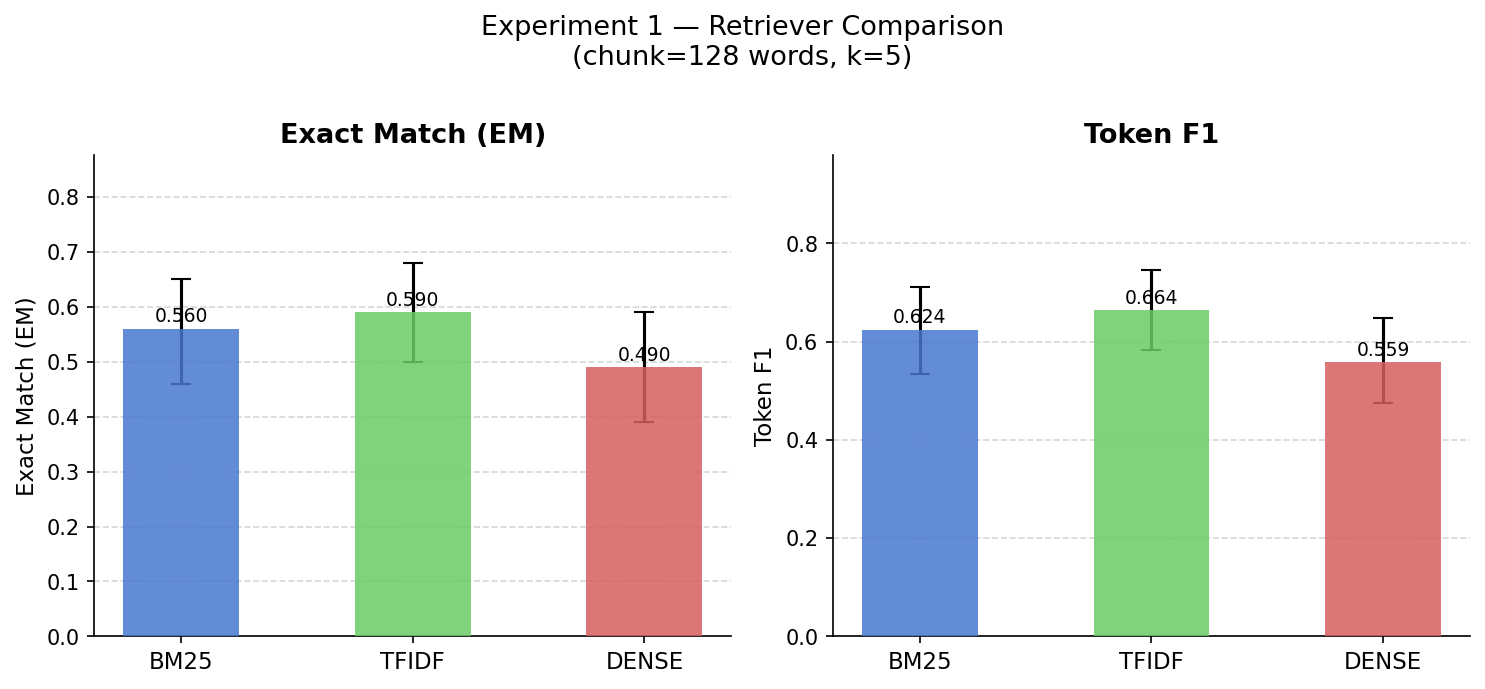

In [29]:
def fig1_retriever_comparison():
    data = _load_summary("exp1_summary")
    if data is None:
        return
    results = data["results"]
    rtypes  = list(results.keys())
    colors  = [PALETTE.get(r, "#888888") for r in rtypes]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match (EM)", "Token F1"]):
        means  = [results[r][metric]["mean"] for r in rtypes]
        lows   = [results[r][metric]["lo"]   for r in rtypes]
        highs  = [results[r][metric]["hi"]   for r in rtypes]
        labels = [r.upper() for r in rtypes]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 1 — Retriever Comparison\n"
        f"(chunk={config.DEFAULT_CHUNK_SIZE} words, k={config.DEFAULT_K})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _savefig("fig1_retriever_comparison.png")
    plt.show()


fig1_retriever_comparison()


00:04:24 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig2_chunk_size.png


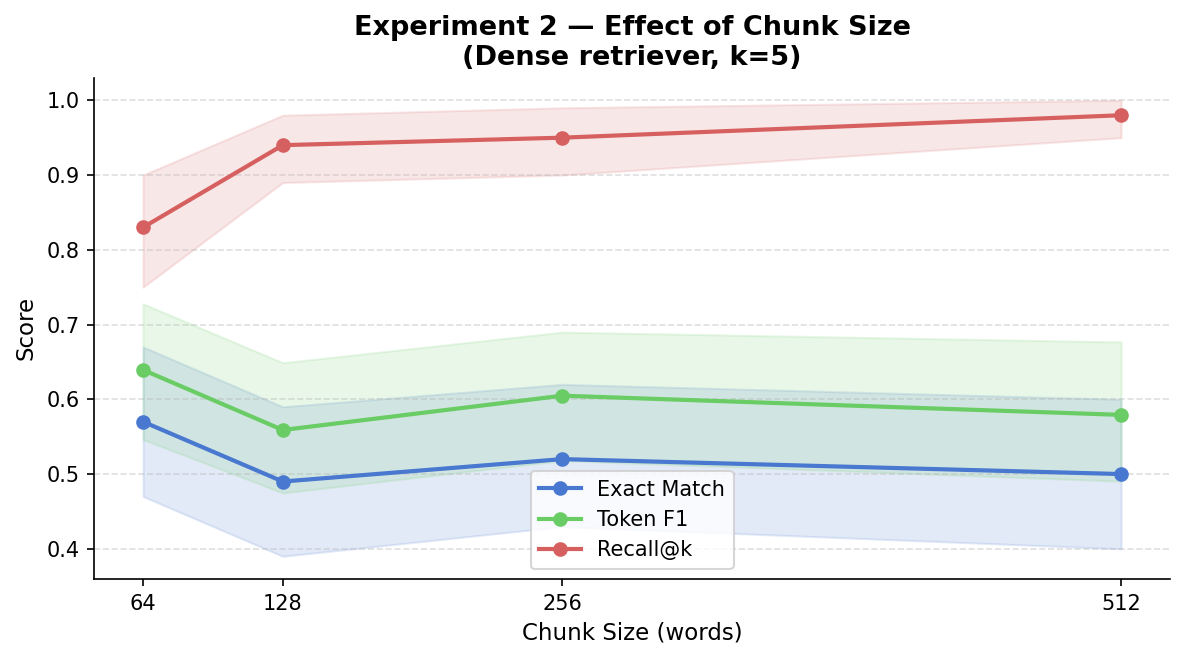

In [30]:
def fig2_chunk_size():
    data = _load_summary("exp2_summary")
    if data is None:
        return
    results = data["results"]

    sizes   = sorted(int(k) for k in results.keys())
    metrics = ["em", "f1", "recall_at_k"]
    labels  = ["Exact Match", "Token F1", "Recall@k"]
    colors  = ["#4878CF", "#6ACC65", "#D65F5F"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric, label, color in zip(metrics, labels, colors):
        means = [results[str(s)][metric]["mean"] for s in sizes]
        lows  = [results[str(s)][metric]["lo"]   for s in sizes]
        highs = [results[str(s)][metric]["hi"]   for s in sizes]
        ax.plot(sizes, means, marker="o", label=label, color=color, linewidth=2)
        ax.fill_between(sizes, lows, highs, alpha=0.15, color=color)

    ax.set_xlabel("Chunk Size (words)", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(
        "Experiment 2 — Effect of Chunk Size\n"
        f"(Dense retriever, k={config.DEFAULT_K})",
        fontsize=13, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_xticks(sizes)
    plt.tight_layout()
    _savefig("fig2_chunk_size.png")
    plt.show()


fig2_chunk_size()


00:04:25 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig3_k_values.png


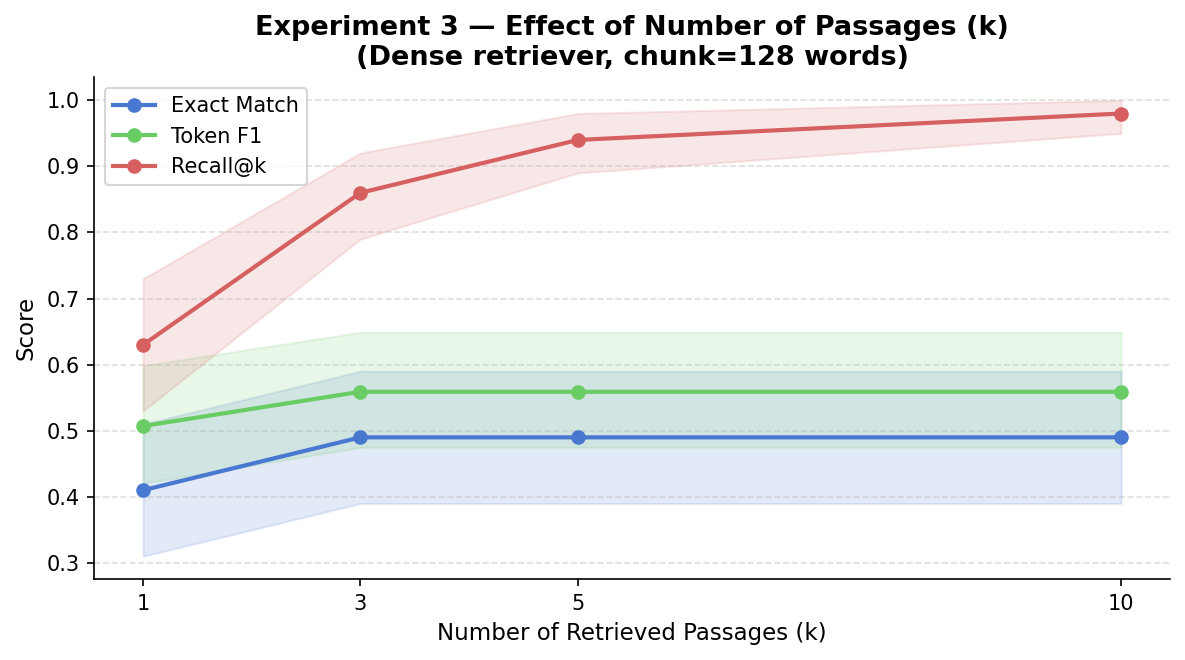

In [31]:
def fig3_k_values():
    data = _load_summary("exp3_summary")
    if data is None:
        return
    results = data["results"]

    ks      = sorted(int(k) for k in results.keys())
    metrics = ["em", "f1", "recall_at_k"]
    labels  = ["Exact Match", "Token F1", "Recall@k"]
    colors  = ["#4878CF", "#6ACC65", "#D65F5F"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric, label, color in zip(metrics, labels, colors):
        means = [results[str(k)][metric]["mean"] for k in ks]
        lows  = [results[str(k)][metric]["lo"]   for k in ks]
        highs = [results[str(k)][metric]["hi"]   for k in ks]
        ax.plot(ks, means, marker="o", label=label, color=color, linewidth=2)
        ax.fill_between(ks, lows, highs, alpha=0.15, color=color)

    ax.set_xlabel("Number of Retrieved Passages (k)", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(
        "Experiment 3 — Effect of Number of Passages (k)\n"
        f"(Dense retriever, chunk={config.DEFAULT_CHUNK_SIZE} words)",
        fontsize=13, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_xticks(ks)
    plt.tight_layout()
    _savefig("fig3_k_values.png")
    plt.show()


fig3_k_values()


00:04:26 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig4_prompt_template.png


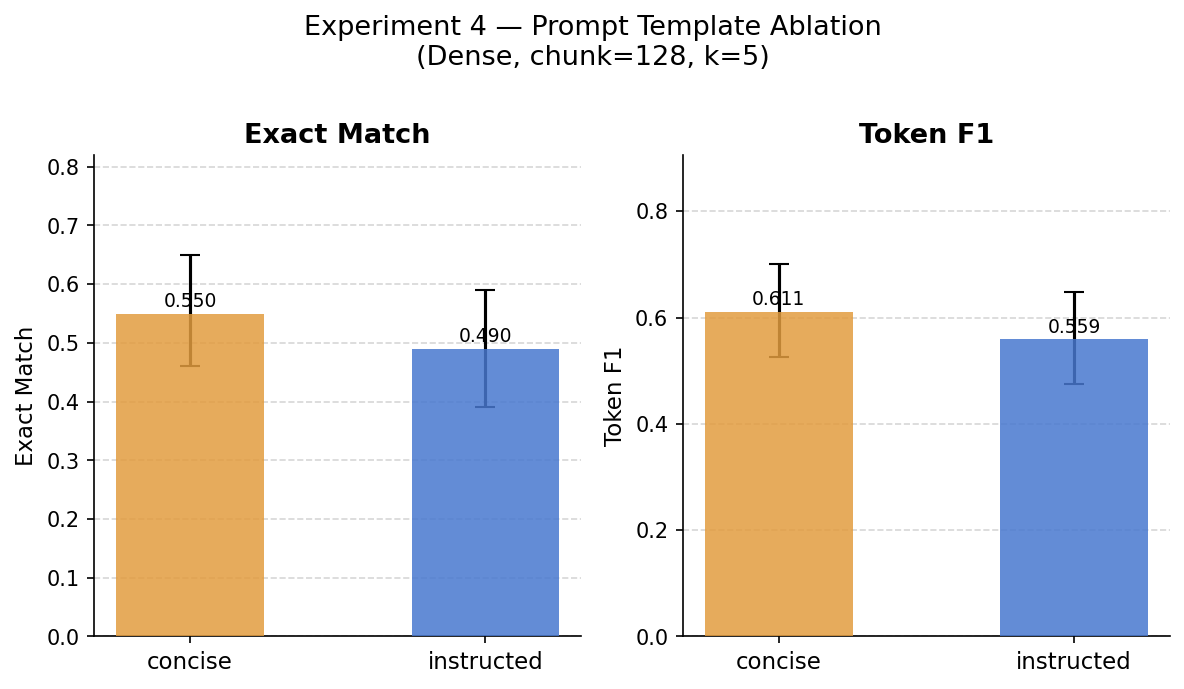

In [32]:
def fig4_prompt_template():
    data = _load_summary("exp4_summary")
    if data is None:
        return
    results = data["results"]

    templates = ["concise", "instructed"]
    colors    = [PALETTE[t] for t in templates]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match", "Token F1"]):
        means = [results[t][metric]["mean"] for t in templates]
        lows  = [results[t][metric]["lo"]   for t in templates]
        highs = [results[t][metric]["hi"]   for t in templates]
        _bar_with_ci(ax, templates, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 4 — Prompt Template Ablation\n"
        f"(Dense, chunk={config.DEFAULT_CHUNK_SIZE}, k={config.DEFAULT_K})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _savefig("fig4_prompt_template.png")
    plt.show()


fig4_prompt_template()


00:04:27 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig5_rag_vs_no_rag.png


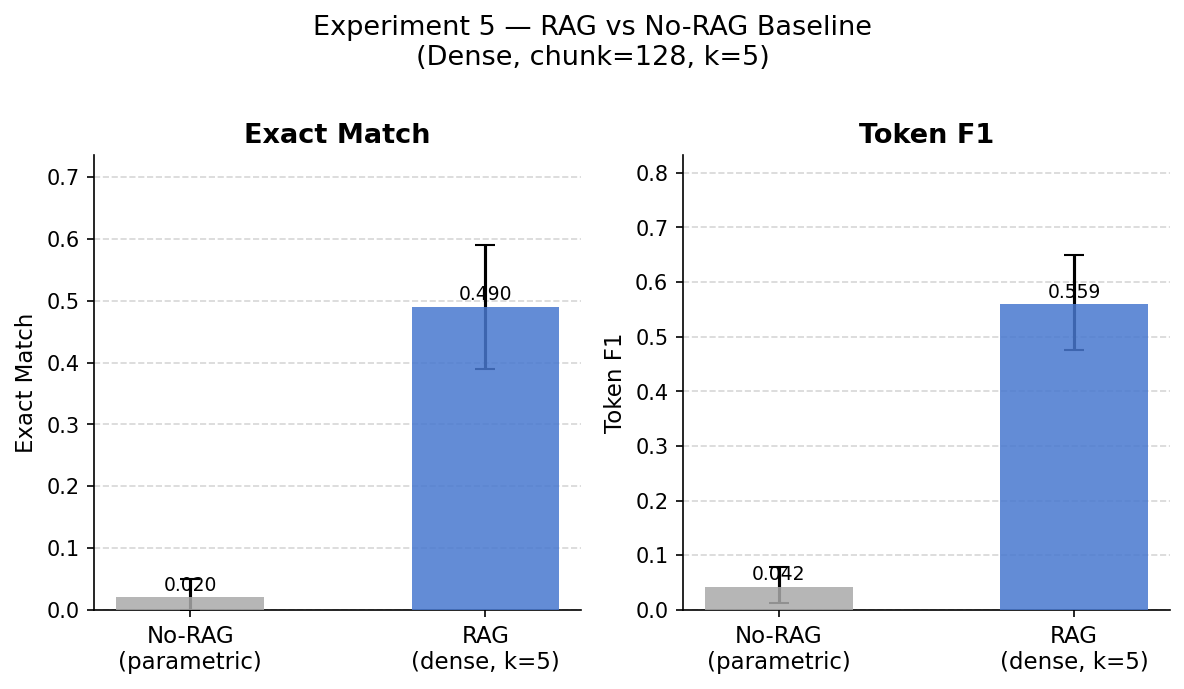

In [33]:
def fig5_rag_vs_no_rag():
    data = _load_summary("exp5_summary")
    if data is None:
        return

    conditions = ["no_rag", "rag"]
    labels     = ["No-RAG\n(parametric)", "RAG\n(dense, k=5)"]
    colors     = [PALETTE[c] for c in conditions]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match", "Token F1"]):
        means = [data[c][metric]["mean"] for c in conditions]
        lows  = [data[c][metric]["lo"]   for c in conditions]
        highs = [data[c][metric]["hi"]   for c in conditions]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 5 — RAG vs No-RAG Baseline\n"
        f"(Dense, chunk={config.DEFAULT_CHUNK_SIZE}, k={config.DEFAULT_K})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _savefig("fig5_rag_vs_no_rag.png")
    plt.show()


fig5_rag_vs_no_rag()


00:04:28 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig6_error_analysis.png


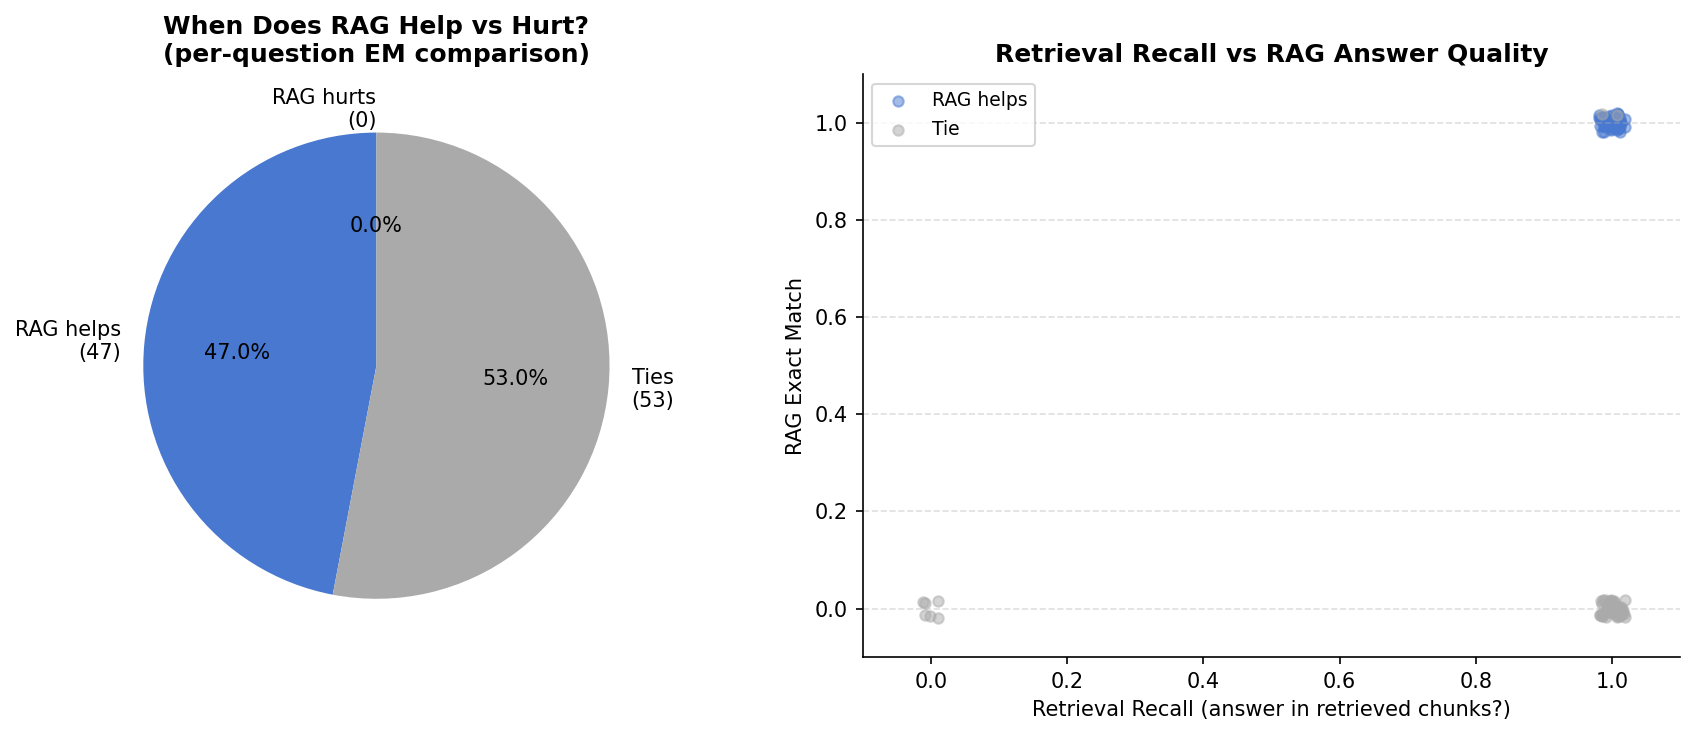

In [34]:
def fig6_error_analysis():
    data = _load_summary("exp5_summary")
    if data is None:
        return

    delta = data.get("delta_analysis", [])
    if not delta:
        logger.warning("No delta_analysis in exp5_summary — skipping fig6.")
        return

    helps = data["delta_counts"]["helps"]
    hurts = data["delta_counts"]["hurts"]
    ties  = data["delta_counts"]["ties"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: win/loss/tie pie
    ax = axes[0]
    wedge_labels = [f"RAG helps\n({helps})", f"Ties\n({ties})", f"RAG hurts\n({hurts})"]
    wedge_sizes  = [helps, ties, hurts]
    wedge_colors = ["#4878CF", "#AAAAAA", "#D65F5F"]
    ax.pie(
        wedge_sizes, labels=wedge_labels, colors=wedge_colors,
        autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10},
    )
    ax.set_title("When Does RAG Help vs Hurt?\n(per-question EM comparison)",
                 fontsize=12, fontweight="bold")

    # Right: recall vs EM scatter
    ax = axes[1]
    recalls = [d["recall"]   for d in delta]
    rag_ems = [d["rag_em"]   for d in delta]
    helps_mask = [d["rag_helps"] for d in delta]
    hurts_mask = [d["rag_hurts"] for d in delta]
    ties_mask  = [1 - d["rag_helps"] - d["rag_hurts"] for d in delta]

    rng = np.random.default_rng(42)
    jitter_x = rng.uniform(-0.02, 0.02, len(delta))
    jitter_y = rng.uniform(-0.02, 0.02, len(delta))
    recalls_j = np.array(recalls, dtype=float) + jitter_x
    rag_ems_j = np.array(rag_ems,  dtype=float) + jitter_y

    for mask, color, label in [
        (helps_mask, "#4878CF", "RAG helps"),
        (ties_mask,  "#AAAAAA", "Tie"),
        (hurts_mask, "#D65F5F", "RAG hurts"),
    ]:
        idx = [i for i, m in enumerate(mask) if m]
        if idx:
            ax.scatter(recalls_j[idx], rag_ems_j[idx],
                       c=color, alpha=0.5, s=25, label=label)

    ax.set_xlabel("Retrieval Recall (answer in retrieved chunks?)", fontsize=10)
    ax.set_ylabel("RAG Exact Match", fontsize=10)
    ax.set_title("Retrieval Recall vs RAG Answer Quality",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    _savefig("fig6_error_analysis.png")
    plt.show()


fig6_error_analysis()


00:04:28 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig7_qualitative.png


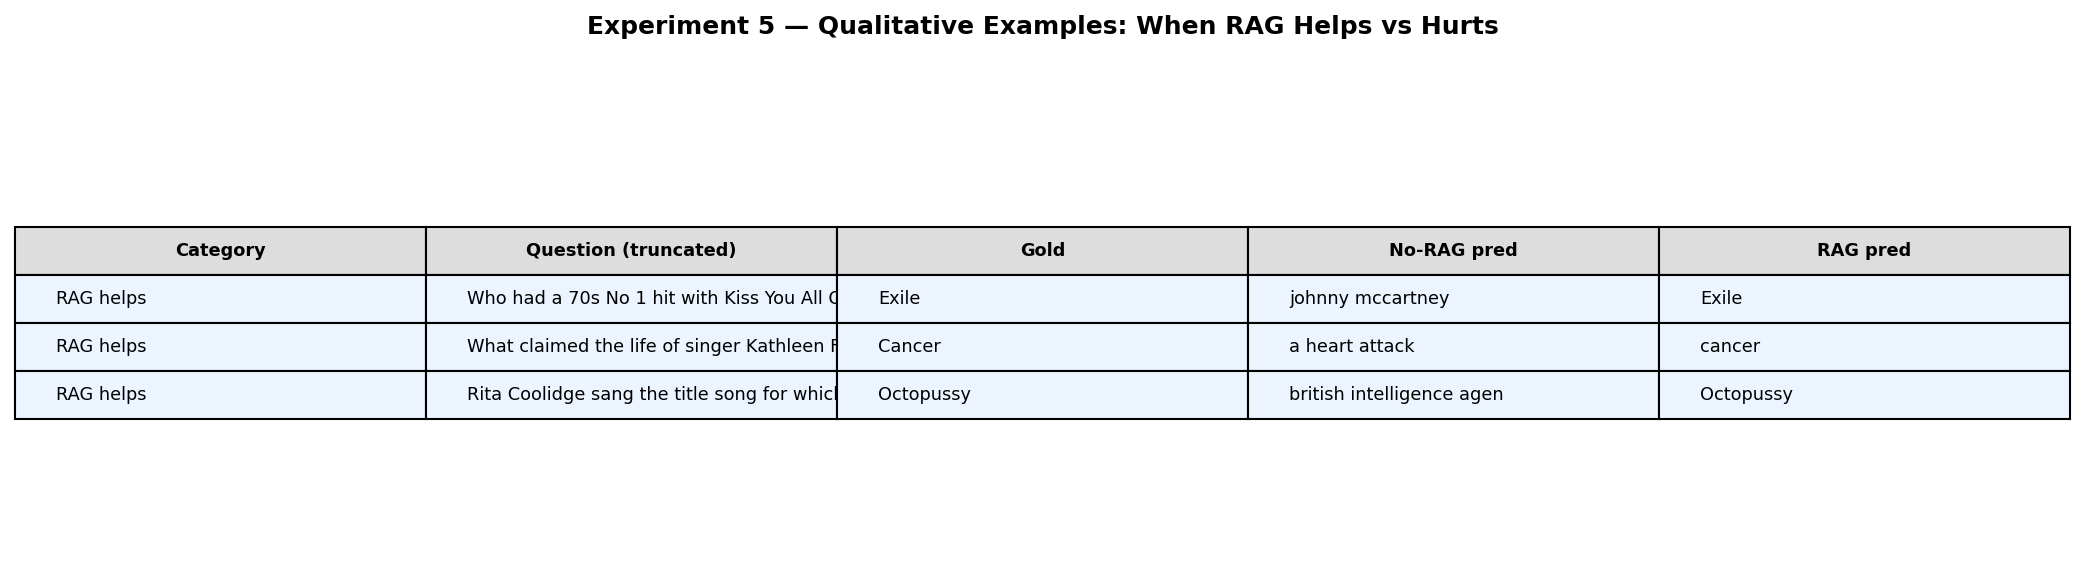

In [35]:
def fig7_qualitative():
    data = _load_summary("exp5_summary")
    if data is None:
        return

    delta = data.get("delta_analysis", [])
    if not delta:
        return

    helps_cases = [d for d in delta if d["rag_helps"] == 1 and d["recall"] == 1.0][:3]
    hurts_cases = [d for d in delta if d["rag_hurts"] == 1][:3]

    fig, ax = plt.subplots(
        figsize=(14, max(4, (len(helps_cases) + len(hurts_cases)) * 1.2))
    )
    ax.axis("off")

    col_labels = ["Category", "Question (truncated)", "Gold",
                  "No-RAG pred", "RAG pred"]
    rows = []
    for d in helps_cases:
        rows.append([
            "RAG helps",
            d["question"][:55] + ("…" if len(d["question"]) > 55 else ""),
            str(d["gold"][0])[:25],
            str(d["no_rag_pred"])[:25],
            str(d["rag_pred"])[:25],
        ])
    for d in hurts_cases:
        rows.append([
            "RAG hurts",
            d["question"][:55] + ("…" if len(d["question"]) > 55 else ""),
            str(d["gold"][0])[:25],
            str(d["no_rag_pred"])[:25],
            str(d["rag_pred"])[:25],
        ])

    if not rows:
        logger.info("Not enough examples for qualitative figure — skipping.")
        plt.close()
        return

    tbl = ax.table(
        cellText=rows, colLabels=col_labels, cellLoc="left", loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.8)

    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#DDDDDD")
            cell.set_text_props(fontweight="bold")
        elif row <= len(helps_cases):
            cell.set_facecolor("#EBF4FF")
        else:
            cell.set_facecolor("#FFF0EE")

    ax.set_title(
        "Experiment 5 — Qualitative Examples: When RAG Helps vs Hurts",
        fontsize=12, fontweight="bold", pad=20,
    )
    plt.tight_layout()
    _savefig("fig7_qualitative.png")
    plt.show()


fig7_qualitative()
